<a href="https://colab.research.google.com/github/narendra974/Pytorch_Bootcamp_ZTM/blob/main/02_Pytorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pytorch Workflow
* Ground Truth Notebook - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/video_notebooks/01_pytorch_workflow_video.ipynb
* Book Verison of Note book https://www.learnpytorch.io/01_pytorch_workflow/
* Ask a Question - https://github.com/mrdbourke/pytorch-deep-learning/discussions

In [1]:
what_were_covering = {
        1: "data (prepare and load)",
        2: "Building Model",
        3: "Fitting the model to data (training)",
        4: "Making Predictions and Evaluating the Model (inference and evaluation)",
        5: "saving and loading a model",
        6: "putting it all together"
}

In [2]:
import torch
from torch import nn
import matplotlib
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

## 1. Data (preparing and loading)

Data can be anything in machine learning.
* excel spreadsheet
* images of any kind
* Video youtube
* Audio like songsa or podcasts
* Text

Machine Learning is a game of two parts.
1. Get Data into a numerical representation.
2. build a model to learn patterns in that numerical representation.

To Showcasse this lets create some data using linear regression formula.

we will use a linear regression formula to make a straight line with known parameters

In [3]:
# Create know parameter.

weight = 0.7
bias = 0.3

#Create a range of numbers.

start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step)
X.shape

torch.Size([50])

In [4]:
# we want row of X's so add one more dimensions.
X = X.unsqueeze(dim=1)
X.shape

torch.Size([50, 1])

In [5]:
# Create Y with X

y = weight * X + bias

X[:5], y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [6]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning)

Lets create a training and test set with our data

In [7]:
training_split = int(0.8*len(X))
X_train, y_train = X[:training_split], y[:training_split]
X_test, y_test = X[training_split:], y[training_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### How might we better visualize our data


In [8]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions
    """
    plt.figure(figsize=(10,7))

    plt.scatter(train_data, train_labels, c="b", s=4, label="training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="test data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="predictions")

    plt.legend(prop={"size":14})

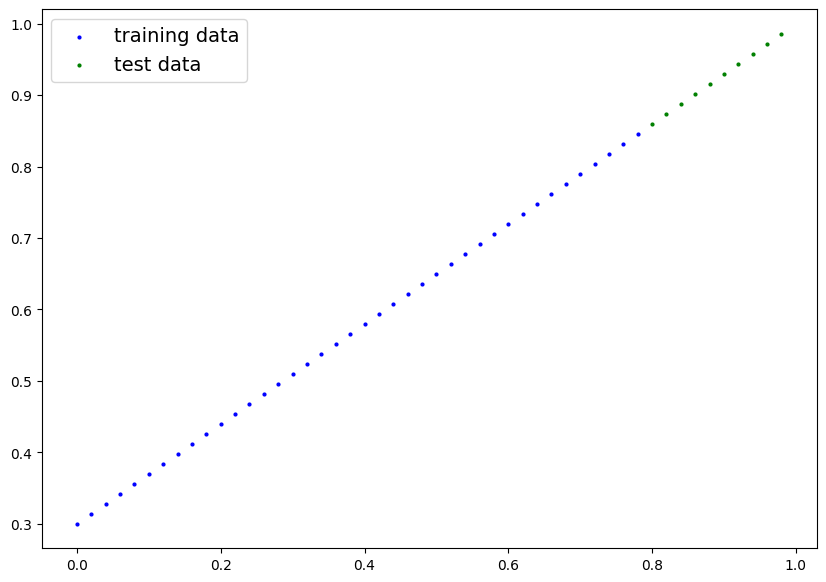

In [9]:
plot_predictions()

### Two Main Algorithms
* Gradient Descent
* Back Propagation

In [10]:
# Create linear regression model class
from torch import nn

class LinearRegressionModelV1(nn.Module): # Almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias

### PyTOrch model building essentials.

* torch.nn - contains all of the building blocks for computational graphs.
* torch.nn.Parameter =
* torch.nn.Module - basse class for all the neual network modules, if you subclass you have to over ride forward function.
* torch.optim - this where the optimizers in Pytorch live, they will help with gradient descent.
* def forward() - All nn.Module subclasses should implement this function.


### Checking the contents of our PyTorch model

Now the model is created, let us see what is there inside.
So we can check our model parameters or whats inside our model using oara

In [11]:
# Create a random seed
torch.manual_seed(42)

#Create an instance of the model.
model_0 = LinearRegressionModelV1()

# Check out the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Predictions using torch.inference_mode()

To Check out models predictive power, lets how well it predicts y_test on X_test

When we pass data through our model, its going to run it through the forward() method


In [13]:
with torch.inference_mode():
  y_preds = model_0(X_test)

with torch.no_grad():  # even torch.no_grad() can also be used, but torch.inference_model also
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

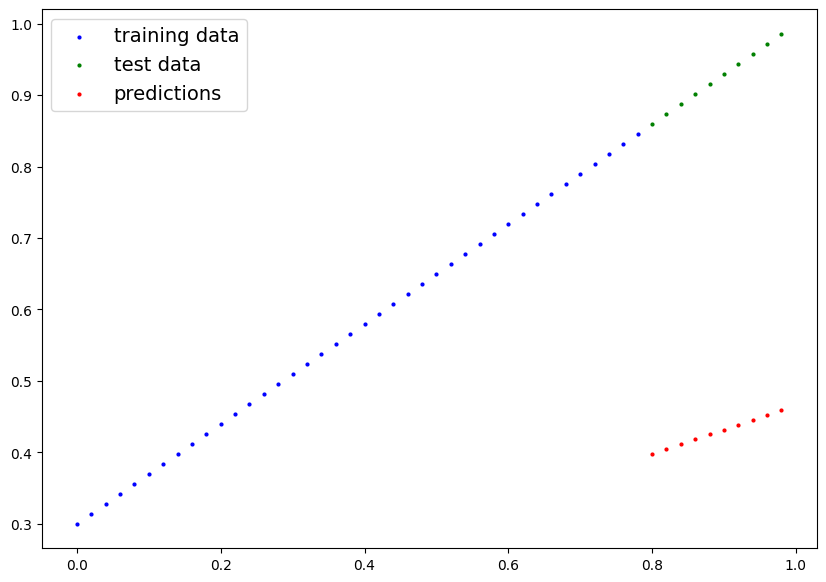

In [14]:
plot_predictions(predictions=y_preds)

### 3. Train the Model

The whole idea of training is for a model to move from some unknown parameters to some known parameters

Or in other words poor representation of the data to good representation of the data.

One way to measure how poor or how wrong your model predictions are is to use a loss function.


* Notes : Loss function may also called cost function or criteria.

* Loss Function : A function to measure how wrong your models predictions are to the ideal outputs.
* Optimizer : Takes loss into account and modify the models parameters.

For Pytorch we need
* Training Loop
* Testing Loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [17]:
# Set u p a Loss Function
loss_fn = nn.L1Loss()

# Setup an Optimizer Stochastic Gradient descent
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # Lr = Learning Rate

### Building a training loop and a testing loop in PyTorch.

A Couple of things we need is a training loop.

0. Loop through the data
1. Forward Pass (this involves data moving through the model's forward function, also called Forward Propagation)
2. Calculate the Loss (Compare forward pass predictions to ground truch labels)
3. Optimizer zero grad
4. Loss Backward -> move backwards through the network to calcualte the gradients of each of the parameters of model w.r.t to the loss.
5. Optimizer Step : use the optimizer to adjust the models parameters to minimize the Loss.

In [18]:
epochs = 200 # An epoch is one loop through the data. This is hyper parameter.

#Tracking experiments
epoch_count = []
loss_values = []
test_loss_values = []

### Training
#0. Loop through the data.
for epoch in range(epochs):
  model_0.train()  # Training Mode in PyTorch sets all the parameters to training mode.

  #1. Forward Pass
  y_pred = model_0(X_train)

  #2. Calculate the Loss.
  loss = loss_fn(y_pred, y_train)
  # print(f"Loss: {loss}")

  #3. Optimizer Zero Grad
  optimizer.zero_grad()

  #4. Perform backpropagation on the loass with respect to the parameters of the model.
  loss.backward()

  #5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default optimizer accumlate through the loop so ... we have to zero them above in step 3

  model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout/batch normalization)
  with torch.inference_mode():
    test_pred = model_0(X_test) ## Do the forward pass.

    #2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

In [19]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

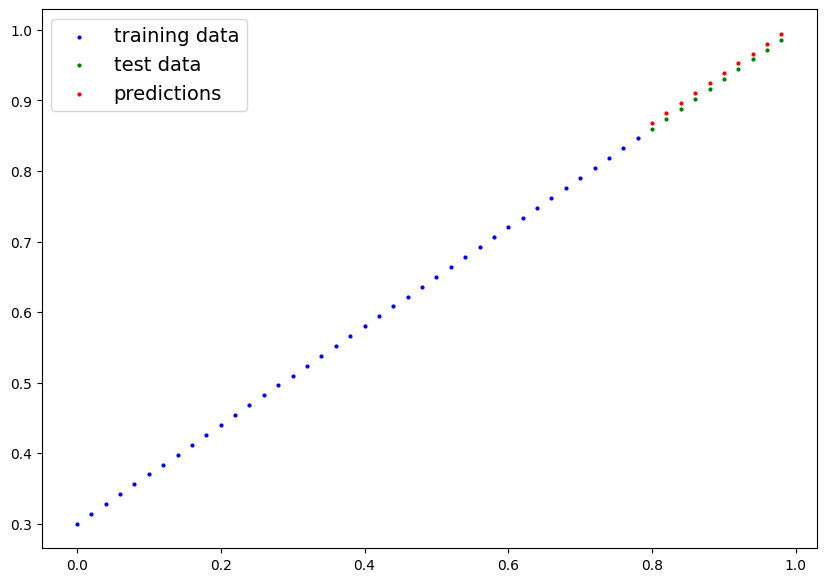

In [20]:
with torch.inference_mode():
  y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)
#

In [22]:
loss_values, test_loss_values

([tensor(0.3129, grad_fn=<MeanBackward0>),
  tensor(0.1977, grad_fn=<MeanBackward0>),
  tensor(0.0891, grad_fn=<MeanBackward0>),
  tensor(0.0531, grad_fn=<MeanBackward0>),
  tensor(0.0454, grad_fn=<MeanBackward0>),
  tensor(0.0417, grad_fn=<MeanBackward0>),
  tensor(0.0382, grad_fn=<MeanBackward0>),
  tensor(0.0348, grad_fn=<MeanBackward0>),
  tensor(0.0313, grad_fn=<MeanBackward0>),
  tensor(0.0279, grad_fn=<MeanBackward0>),
  tensor(0.0245, grad_fn=<MeanBackward0>),
  tensor(0.0210, grad_fn=<MeanBackward0>),
  tensor(0.0176, grad_fn=<MeanBackward0>),
  tensor(0.0142, grad_fn=<MeanBackward0>),
  tensor(0.0107, grad_fn=<MeanBackward0>),
  tensor(0.0073, grad_fn=<MeanBackward0>),
  tensor(0.0039, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>)],
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.08

In [23]:
# They are tensors, we should move them to numpy.

Text(0.5, 0, 'Epochs')

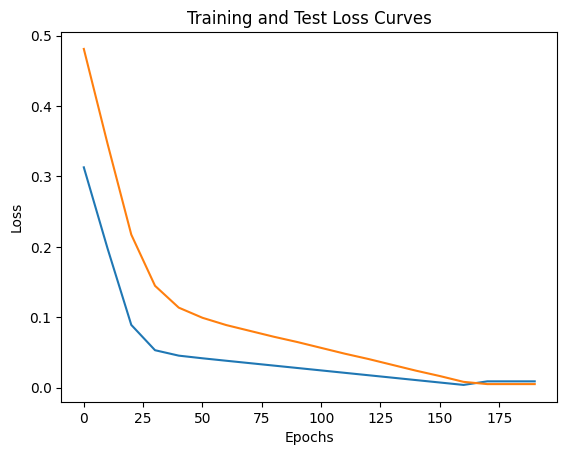

In [29]:
import numpy as np

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Training Loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")

### Writing a code to save the model

There are three main methods you should know about
1. torch.save() - allows you save a PyTorch Object in Pythongs Pickle format.
2. torch.load() - allows you load a saved PyTorch Object
3. torch.nn.Module.load_state_dict() - This allows to load a models saved state dictionary